# 🌲 Notebook 1 — Méthodes d'Ensemble (AML)

**Master 1 Intelligence Artificielle — Université de Nouakchott (UN-FST) — 2026**
Groupe : Mohamed Salem Ebnou Oubeid (C34613) · Fatimata Issa Saw (C21304) · Oussama Sid'Ahmed Hedy (C34603)

---

Ce notebook couvre les **méthodes d'ensemble** présentées dans la partie AML — Paire 1.
Chaque section correspond directement à un groupe de slides.

## Table des matières
1. Imports et configuration
2. Chargement et exploration des données
3. Décomposition Biais-Variance
4. Théorème de Condorcet — Simulation Monte Carlo
5. Vote majoritaire — implémentation from scratch (NumPy)
6. Bagging et Random Forest
7. Boosting — AdaBoost et Gradient Boosting
8. Stacking
9. Comparaison globale des modèles
10. Importance des features — heatmap des pixels
11. Lien ML ↔ DL : Dropout = Bagging implicite


## 1. Imports et configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import comb

from sklearn.datasets import load_digits, make_classification
from sklearn.model_selection import (
    train_test_split, cross_val_score, learning_curve
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, BaggingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# XGBoost est optionnel
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    print("✅ XGBoost disponible")
except ImportError:
    HAS_XGB = False
    print("⚠️  XGBoost non installé — exécuter : pip install xgboost")

# Style graphique global
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

# Couleurs UN-FST
C_GREEN  = '#3A8E5B'
C_GOLD   = '#E8B608'
C_BLUE   = '#1ea8c4'
C_RED    = '#e74c3c'
C_BG     = '#FEEFEE'

print("✅ Imports OK")


✅ XGBoost disponible
✅ Imports OK


## 2. Chargement et exploration des données

Nous utilisons le dataset **Digits** de scikit-learn : 1 797 images de chiffres manuscrits (0–9),
représentées par 64 pixels (8×8). C'est une version allégée de MNIST, idéale pour des expériences rapides.


Dimensions : (1797, 64)   (n_samples × n_features)
Classes    : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  (10 chiffres)
Train : 1437 | Test : 360


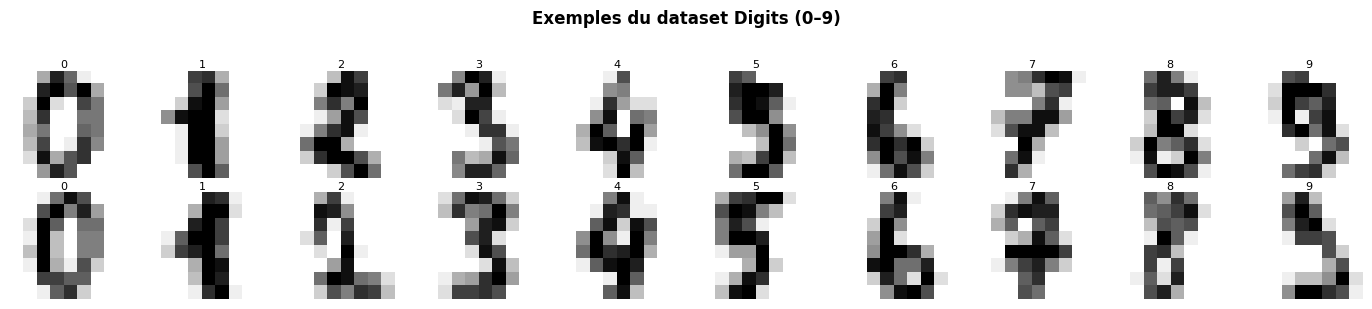

In [2]:
# Chargement du dataset Digits
digits = load_digits()
X, y = digits.data / 16.0, digits.target   # normalisation dans [0, 1]

# Division entraînement / test stratifiée (80 % / 20 %)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dimensions : {X.shape}   (n_samples × n_features)")
print(f"Classes    : {np.unique(y).tolist()}  ({len(np.unique(y))} chiffres)")
print(f"Train : {X_train.shape[0]} | Test : {X_test.shape[0]}")

# Affichage d'exemples
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray_r')
    ax.set_title(str(digits.target[i]), fontsize=8, pad=2)
    ax.axis('off')
plt.suptitle("Exemples du dataset Digits (0–9)", fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 3. Décomposition Biais-Variance

L'erreur totale d'un modèle se décompose en :

$$E\bigl[(y - \hat{y})^2\bigr] = \underbrace{\text{Biais}^2}_{\text{erreur systématique}} + \underbrace{\text{Variance}}_{\text{sensibilité aux données}} + \underbrace{\sigma^2}_{\text{bruit irréductible}}$$

- **Biais élevé** → modèle trop simple → *sous-apprentissage*
- **Variance élevée** → modèle trop complexe → *sur-apprentissage*

Les méthodes d'ensemble corrigent cela :
- **Bagging** → réduit la **variance**
- **Boosting** → réduit le **biais**


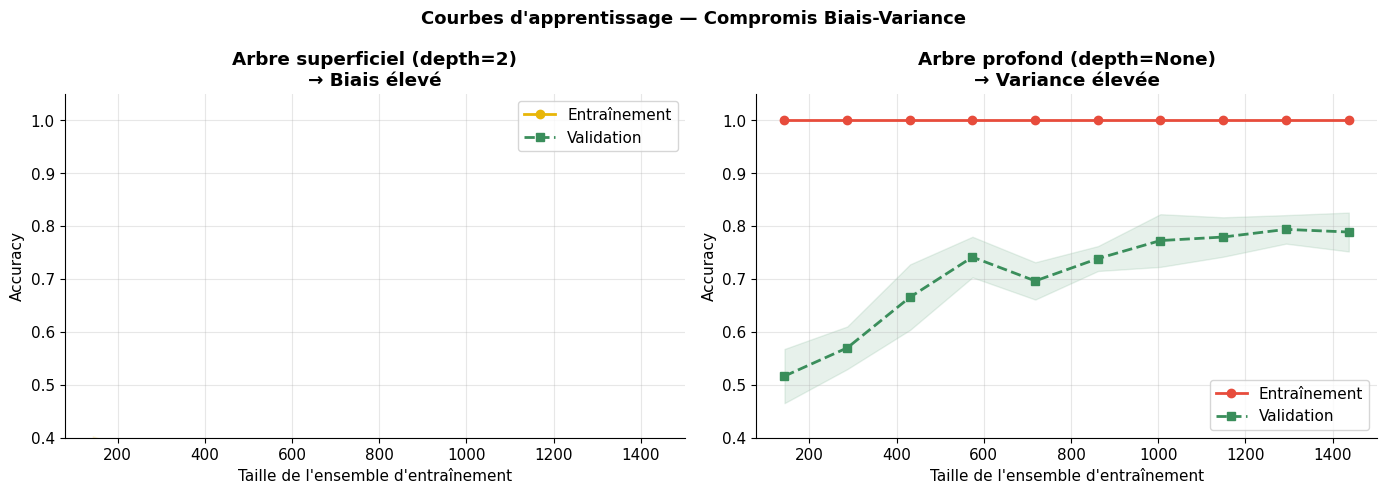

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

configs = [
    (DecisionTreeClassifier(max_depth=2, random_state=42),
     'Arbre superficiel (depth=2)\n→ Biais élevé', C_GOLD),
    (DecisionTreeClassifier(max_depth=None, random_state=42),
     'Arbre profond (depth=None)\n→ Variance élevée', C_RED),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (clf, titre, couleur) in zip(axes, configs):
    tailles, tr_sc, val_sc = learning_curve(
        clf, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )
    tr_m, tr_s   = tr_sc.mean(1),  tr_sc.std(1)
    val_m, val_s = val_sc.mean(1), val_sc.std(1)

    ax.plot(tailles, tr_m,  'o-', color=couleur,  lw=2, label='Entraînement')
    ax.plot(tailles, val_m, 's--', color=C_GREEN, lw=2, label='Validation')
    ax.fill_between(tailles, tr_m - tr_s,  tr_m + tr_s,  alpha=0.12, color=couleur)
    ax.fill_between(tailles, val_m - val_s, val_m + val_s, alpha=0.12, color=C_GREEN)
    ax.set_title(titre, fontweight='bold')
    ax.set_xlabel("Taille de l'ensemble d'entraînement")
    ax.set_ylabel("Accuracy")
    ax.set_ylim([0.4, 1.05])
    ax.legend()

plt.suptitle("Courbes d'apprentissage — Compromis Biais-Variance", fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Théorème de Condorcet — Simulation Monte Carlo

Si chaque classifieur a une probabilité $p > 0{,}5$ d'avoir raison, alors la probabilité que
le **vote majoritaire** soit correct augmente avec le nombre de classifieurs $N$ :

$$P(\text{majorité correcte}) = \sum_{k=\lfloor N/2 \rfloor + 1}^{N} \binom{N}{k}\, p^k\, (1-p)^{N-k}$$

**Intuition** : plus on ajoute de classifieurs indépendants (et meilleurs que le hasard),
plus l'ensemble converge vers la certitude.


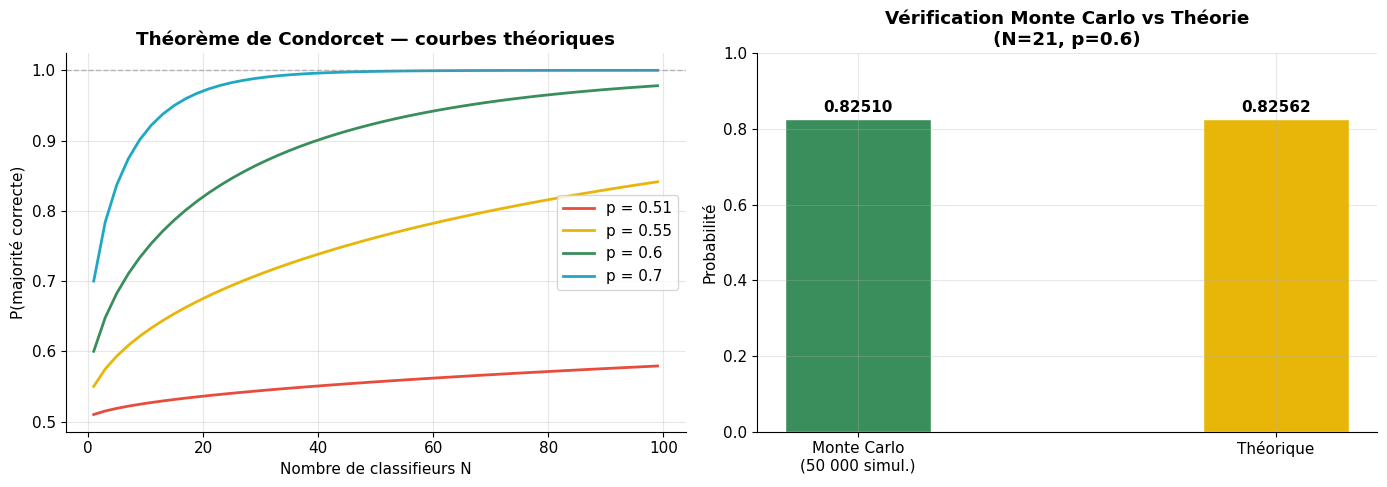

Monte Carlo : 0.82510 | Théorique : 0.82562 | Δ = 0.00052


In [6]:
def prob_condorcet(N, p):
    """
    Probabilité que le vote majoritaire sur N classifieurs soit correct.

    Paramètres
    ----------
    N : int   — nombre de classifieurs (doit être impair)
    p : float — probabilité qu'un classifieur individuel soit correct
    """
    k_min = N // 2 + 1
    return sum(
        comb(N, k, exact=True) * (p ** k) * ((1 - p) ** (N - k))
        for k in range(k_min, N + 1)
    )


# ── Courbes théoriques pour différentes valeurs de p ──
N_vals = np.arange(1, 101, 2)          # nombres impairs de 1 à 99
p_vals = [0.51, 0.55, 0.60, 0.70]
couleurs_p = [C_RED, C_GOLD, C_GREEN, C_BLUE]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for p, c in zip(p_vals, couleurs_p):
    probs = [prob_condorcet(N, p) for N in N_vals]
    axes[0].plot(N_vals, probs, lw=2, color=c, label=f'p = {p}')
axes[0].axhline(1.0, color='gray', ls='--', lw=1, alpha=0.5)
axes[0].set_xlabel("Nombre de classifieurs N")
axes[0].set_ylabel("P(majorité correcte)")
axes[0].set_title("Théorème de Condorcet — courbes théoriques", fontweight='bold')
axes[0].legend()

# ── Vérification Monte Carlo (N=21, p=0.60) ──
np.random.seed(42)
N_mc, p_mc, n_simul = 21, 0.60, 50_000
votes = np.random.binomial(1, p_mc, size=(n_simul, N_mc))
mc_prob = (votes.sum(axis=1) > N_mc / 2).mean()
th_prob  = prob_condorcet(N_mc, p_mc)

axes[1].bar(['Monte Carlo\n(50 000 simul.)', 'Théorique'],
            [mc_prob, th_prob],
            color=[C_GREEN, C_GOLD], edgecolor='white', width=0.35)
axes[1].set_ylim([0, 1])
axes[1].set_ylabel("Probabilité")
axes[1].set_title(f"Vérification Monte Carlo vs Théorie\n(N={N_mc}, p={p_mc})",
                  fontweight='bold')
for i, v in enumerate([mc_prob, th_prob]):
    axes[1].text(i, v + 0.02, f'{v:.5f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print(f"Monte Carlo : {mc_prob:.5f} | Théorique : {th_prob:.5f} | Δ = {abs(mc_prob-th_prob):.5f}")

## 5. Vote majoritaire — implémentation from scratch

Avant d'utiliser scikit-learn, construisons un classifieur par **vote majoritaire** minimal
en NumPy pur pour bien comprendre le mécanisme.


In [7]:
class MajorityVoteClassifier:
    """
    Classifieur par vote majoritaire (plurality voting).
    Combine N classifieurs de base : chaque exemple est assigné à la classe
    la plus fréquemment prédite parmi les N modèles.
    """

    def __init__(self, classifieurs):
        self.classifieurs = classifieurs

    def fit(self, X, y):
        """Entraîne tous les classifieurs de base sur (X, y)."""
        for clf in self.classifieurs:
            clf.fit(X, y)
        return self

    def predict(self, X):
        """Vote à la pluralité : retourne la classe majoritaire."""
        # Matrice de prédictions : shape (n_classifieurs, n_samples)
        preds = np.vstack([clf.predict(X) for clf in self.classifieurs])
        # Pour chaque échantillon, prend la classe la plus fréquente
        result = np.apply_along_axis(
            lambda votes: np.bincount(votes.astype(int)).argmax(),
            axis=0, arr=preds
        )
        return result

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))


# ── Test : 3 arbres de décision avec profondeurs différentes ──
base_clfs = [
    DecisionTreeClassifier(max_depth=3, random_state=0),
    DecisionTreeClassifier(max_depth=5, random_state=1),
    DecisionTreeClassifier(max_depth=8, random_state=2),
]

mvc = MajorityVoteClassifier(base_clfs)
mvc.fit(X_train, y_train)

acc_ind = [clf.score(X_test, y_test) for clf in base_clfs]
acc_ens = mvc.score(X_test, y_test)

print("Accuracies individuelles :")
for i, acc in enumerate(acc_ind, 1):
    print(f"  Arbre depth={3*i} : {acc:.4f}")
print(f"Vote majoritaire    : {acc_ens:.4f}")
print(f"Gain vs moyenne     : +{acc_ens - np.mean(acc_ind):.4f}")


Accuracies individuelles :
  Arbre depth=3 : 0.4833
  Arbre depth=6 : 0.6778
  Arbre depth=9 : 0.8250
Vote majoritaire    : 0.7028
Gain vs moyenne     : +0.0407


## 6. Bagging et Random Forest

**Bagging** (Bootstrap Aggregating) :
1. Tire $T$ sous-ensembles *avec remise* de taille $n$ depuis les données d'entraînement
2. Entraîne un modèle indépendant sur chaque sous-ensemble
3. Agrège les prédictions par vote (classification) ou moyenne (régression)

**Random Forest** = Bagging + sélection aléatoire de $\sqrt{p}$ features à chaque nœud de l'arbre.
Cette double source d'aléatoire décoarréle les arbres et réduit davantage la variance.


In [8]:
# ── Comparaison : arbre seul / Bagging / Random Forest ──

resultats = {}

# 1. Arbre de décision seul
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
resultats['Arbre seul'] = accuracy_score(y_test, dt.predict(X_test))

# 2. Bagging simple (arbres sans sélection de features)
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=0),
    n_estimators=100, bootstrap=True, random_state=42, n_jobs=-1
)
bag.fit(X_train, y_train)
resultats['Bagging (100 arbres)'] = accuracy_score(y_test, bag.predict(X_test))

# 3. Random Forest avec différents nombres d'arbres
for n in [10, 50, 100, 200]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    resultats[f'Random Forest (n={n})'] = accuracy_score(y_test, rf.predict(X_test))

print(f"{'Modèle':<30} {'Accuracy':>10}")
print('-' * 42)
for nom, acc in resultats.items():
    barre = '█' * int(acc * 40)
    print(f"{nom:<30} {acc:.4f}  {barre}")


Modèle                           Accuracy
------------------------------------------
Arbre seul                     0.8250  █████████████████████████████████
Bagging (100 arbres)           0.9250  █████████████████████████████████████
Random Forest (n=10)           0.9361  █████████████████████████████████████
Random Forest (n=50)           0.9583  ██████████████████████████████████████
Random Forest (n=100)          0.9611  ██████████████████████████████████████
Random Forest (n=200)          0.9639  ██████████████████████████████████████


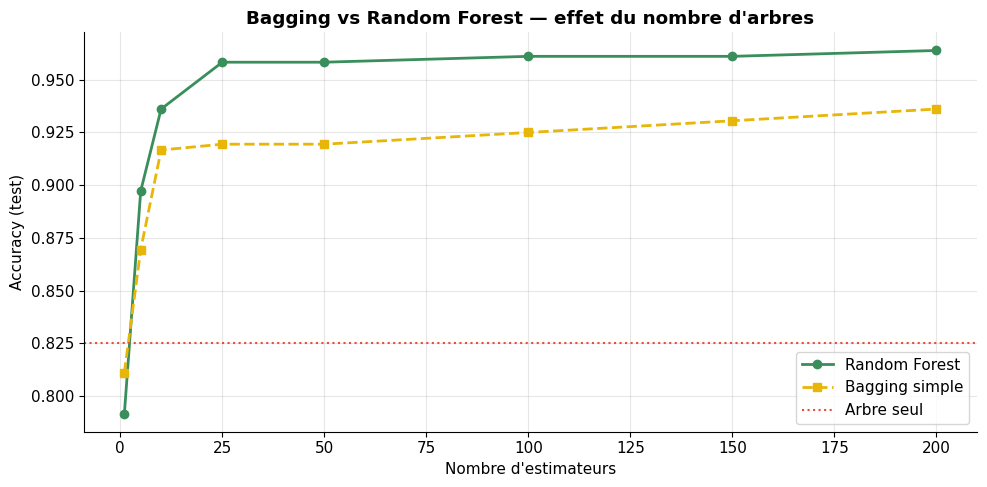

In [9]:
# ── Effet du nombre d'arbres sur la performance ──
n_range = [1, 5, 10, 25, 50, 100, 150, 200]
acc_rf_list, acc_bag_list = [], []

for n in n_range:
    rf_tmp  = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    bag_tmp = BaggingClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf_tmp.fit(X_train, y_train)
    bag_tmp.fit(X_train, y_train)
    acc_rf_list.append(accuracy_score(y_test, rf_tmp.predict(X_test)))
    acc_bag_list.append(accuracy_score(y_test, bag_tmp.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(n_range, acc_rf_list,  'o-',  color=C_GREEN, lw=2, label='Random Forest')
plt.plot(n_range, acc_bag_list, 's--', color=C_GOLD,  lw=2, label='Bagging simple')
plt.axhline(resultats['Arbre seul'], color=C_RED, ls=':', lw=1.5, label='Arbre seul')
plt.xlabel("Nombre d'estimateurs")
plt.ylabel("Accuracy (test)")
plt.title("Bagging vs Random Forest — effet du nombre d'arbres", fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


## 7. Boosting — AdaBoost et Gradient Boosting

Contrairement au Bagging (parallèle), le **Boosting** est **séquentiel** :
chaque nouvel estimateur se concentre sur les erreurs du précédent.

- **AdaBoost** : augmente le poids des exemples mal classifiés à chaque itération
- **Gradient Boosting** : descente de gradient dans l'espace fonctionnel (Friedman, 2001)
- **XGBoost** : Gradient Boosting avec régularisation L1/L2 et parallélisation


In [10]:
# ── AdaBoost ──
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # classifieurs faibles (stumps)
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)
ada.fit(X_train, y_train)

# ── Gradient Boosting ──
gb = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
)
gb.fit(X_train, y_train)

acc_ada = accuracy_score(y_test, ada.predict(X_test))
acc_gb  = accuracy_score(y_test, gb.predict(X_test))

print(f"AdaBoost          : {acc_ada:.4f}")
print(f"Gradient Boosting : {acc_gb:.4f}")

# ── XGBoost (si disponible) ──
if HAS_XGB:
    xgb = XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=4,
        eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0
    )
    xgb.fit(X_train, y_train)
    acc_xgb = accuracy_score(y_test, xgb.predict(X_test))
    print(f"XGBoost           : {acc_xgb:.4f}")


AdaBoost          : 0.8250
Gradient Boosting : 0.9556
XGBoost           : 0.9500


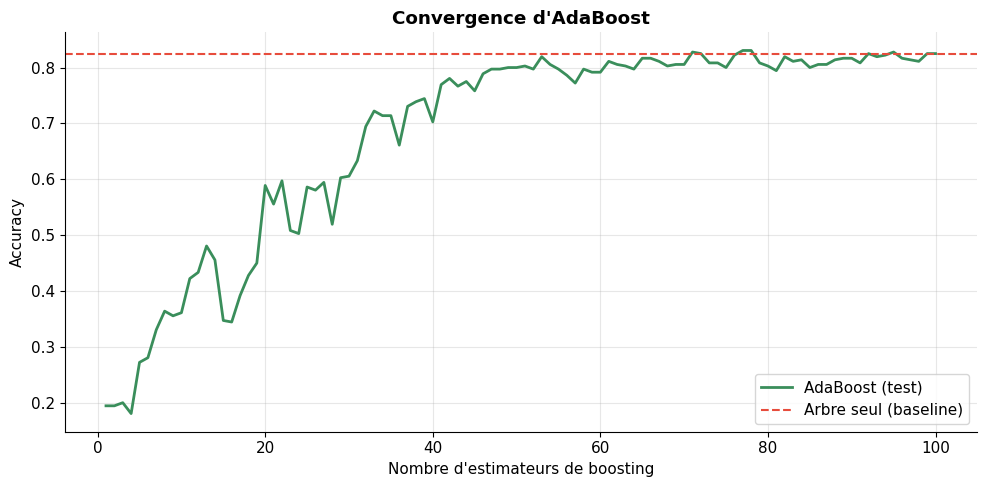

In [11]:
# ── Convergence d'AdaBoost au fil des itérations ──
# staged_score() retourne l'accuracy à chaque étape du boosting
ada_scores = list(ada.staged_score(X_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(ada_scores) + 1), ada_scores, color=C_GREEN, lw=2,
         label='AdaBoost (test)')
plt.axhline(resultats['Arbre seul'], color=C_RED, ls='--', lw=1.5,
            label='Arbre seul (baseline)')
plt.xlabel("Nombre d'estimateurs de boosting")
plt.ylabel("Accuracy")
plt.title("Convergence d'AdaBoost", fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


## 8. Stacking (Empilement)

Le **Stacking** utilise un **méta-apprenant** (niveau 2) pour combiner les prédictions
de plusieurs modèles de base (niveau 1).

Pour éviter la fuite de données, les prédictions de niveau 1 sont générées en
**validation croisée out-of-fold** : le méta-modèle ne voit jamais les prédictions
calculées sur les mêmes données que celles utilisées pour entraîner les modèles de base.


In [12]:
# Modèles de base (niveau 1) — diversité délibérée
base_estimators = [
    ('arbre_3',  DecisionTreeClassifier(max_depth=3, random_state=42)),
    ('arbre_7',  DecisionTreeClassifier(max_depth=7, random_state=42)),
    ('rf_50',    RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)),
    ('ada_50',   AdaBoostClassifier(n_estimators=50, random_state=42)),
]

# Méta-apprenant (niveau 2) — régression logistique (simple et interprétable)
meta = LogisticRegression(max_iter=1000, random_state=42)

# Stacking avec validation croisée 5-fold pour les prédictions OOF
stack = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta,
    cv=5,
    n_jobs=-1,
    passthrough=False
)
stack.fit(X_train, y_train)
acc_stack = accuracy_score(y_test, stack.predict(X_test))
print(f"Stacking (4 modèles + LR) : {acc_stack:.4f}")


Stacking (4 modèles + LR) : 0.9417


## 9. Comparaison globale des modèles

Modèle                             Accuracy    Temps (s)
──────────────────────────────────────────────────────────
Random Forest (100)                  0.9611         1.30
XGBoost (100)                        0.9583         0.48
Gradient Boosting (100)              0.9556        12.61
Stacking                             0.9417         2.96
Bagging (100)                        0.9250         4.09
AdaBoost (100)                       0.8306         1.38
Arbre (profond)                      0.8250         0.07
Arbre (depth=5)                      0.6694         0.02


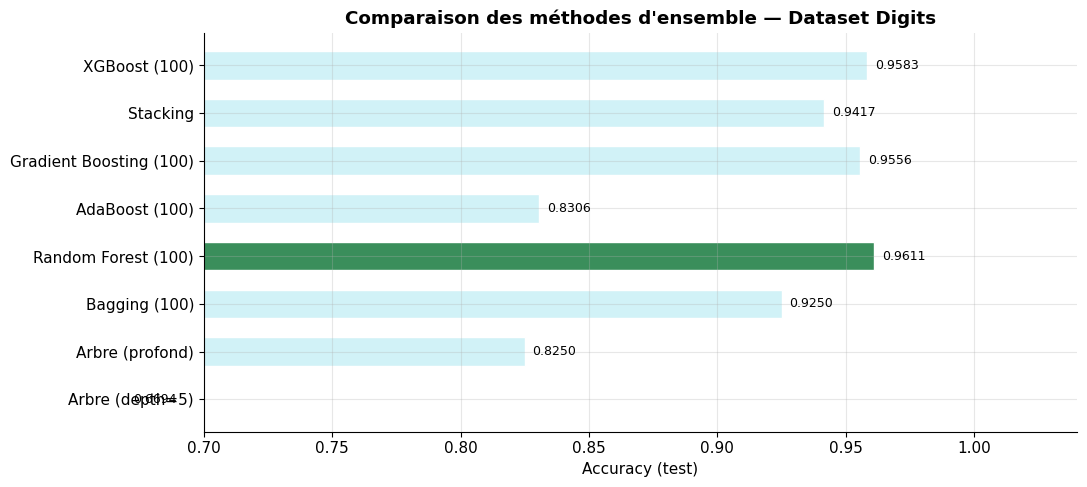

In [13]:
import time

# Dictionnaire de tous les modèles à comparer
modeles = {
    'Arbre (depth=5)':         DecisionTreeClassifier(max_depth=5, random_state=42),
    'Arbre (profond)':         DecisionTreeClassifier(random_state=42),
    'Bagging (100)':           BaggingClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Random Forest (100)':     RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'AdaBoost (100)':          AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting (100)': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Stacking':                StackingClassifier(
                                    estimators=base_estimators,
                                    final_estimator=LogisticRegression(max_iter=1000),
                                    cv=5, n_jobs=-1),
}
if HAS_XGB:
    modeles['XGBoost (100)'] = XGBClassifier(
        n_estimators=100, eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0
    )

res = {}
for nom, clf in modeles.items():
    t0 = time.time()
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    res[nom] = {'Accuracy': acc, 'Temps_s': round(time.time() - t0, 2)}

# Tableau
print(f"{'Modèle':<32} {'Accuracy':>10} {'Temps (s)':>12}")
print('─' * 58)
for nom, r in sorted(res.items(), key=lambda x: -x[1]['Accuracy']):
    print(f"{nom:<32} {r['Accuracy']:>10.4f} {r['Temps_s']:>12.2f}")

# Barplot
noms = list(res.keys())
accs = [res[n]['Accuracy'] for n in noms]
best = max(accs)
colors_bar = [C_GREEN if a == best else '#D1F2F7' for a in accs]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(noms, accs, color=colors_bar, edgecolor='white', height=0.6)
ax.set_xlim([0.70, 1.04])
ax.set_xlabel("Accuracy (test)")
ax.set_title("Comparaison des méthodes d'ensemble — Dataset Digits", fontweight='bold')
for bar, acc in zip(bars, accs):
    ax.text(acc + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{acc:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


## 10. Importance des features — Heatmap des pixels

Le Random Forest calcule l'**importance de chaque feature** (pixel) via la baisse moyenne
d'impureté (MDI — Mean Decrease Impurity). La visualisation en heatmap révèle
les zones de l'image les plus discriminantes pour la classification.


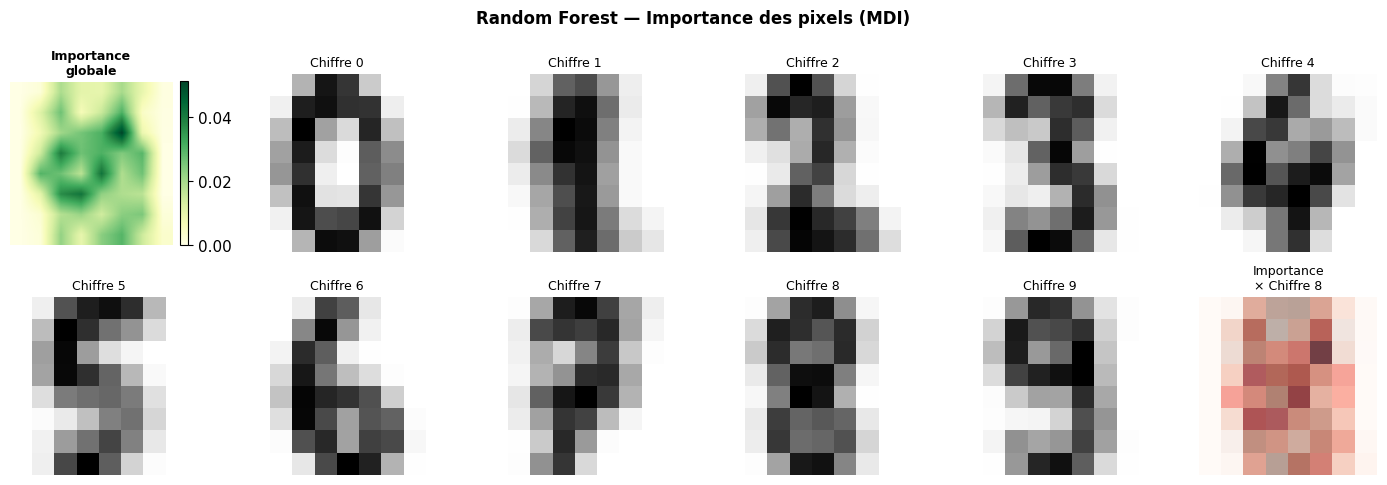

In [14]:
# Entraîner un Random Forest pour l'analyse d'importance
rf_imp = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_imp.fit(X_train, y_train)

importances = rf_imp.feature_importances_.reshape(8, 8)  # reshape en grille 8×8

fig, axes = plt.subplots(2, 6, figsize=(14, 5))

# ── Ligne 1 : importance globale + chiffres moyens par classe ──
im = axes[0, 0].imshow(importances, cmap='YlGn', interpolation='bilinear')
axes[0, 0].set_title("Importance\nglobale", fontsize=9, fontweight='bold')
axes[0, 0].axis('off')
plt.colorbar(im, ax=axes[0, 0], fraction=0.046, pad=0.04)

for c in range(5):
    mean_img = X[y == c].mean(axis=0).reshape(8, 8)
    axes[0, c + 1].imshow(mean_img, cmap='gray_r')
    axes[0, c + 1].set_title(f"Chiffre {c}", fontsize=9)
    axes[0, c + 1].axis('off')

for c in range(5, 10):
    mean_img = X[y == c].mean(axis=0).reshape(8, 8)
    axes[1, c - 5].imshow(mean_img, cmap='gray_r')
    axes[1, c - 5].set_title(f"Chiffre {c}", fontsize=9)
    axes[1, c - 5].axis('off')

# ── Importance superposée sur chiffre 8 ──
axes[1, 5].imshow(X[y == 8].mean(axis=0).reshape(8, 8), cmap='gray_r', alpha=0.6)
axes[1, 5].imshow(importances, cmap='Reds', alpha=0.5)
axes[1, 5].set_title("Importance\n× Chiffre 8", fontsize=9)
axes[1, 5].axis('off')

plt.suptitle("Random Forest — Importance des pixels (MDI)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 11. Lien ML ↔ DL : Dropout = Bagging implicite

C'est le **pont clé** de notre présentation :

> Un réseau de neurones avec **Dropout** peut être interprété comme un **ensemble implicite**
> de $2^M$ sous-réseaux, où $M$ est le nombre de neurones avec dropout.

| | Bagging (explicite) | Dropout (implicite) |
|---|---|---|
| Sous-modèles | $T$ modèles indépendants | $2^M$ sous-réseaux imbriqués |
| Poids | Indépendants par modèle | **Partagés** entre sous-réseaux |
| Entraînement | Parallèle (indépendant) | Séquentiel (un masque par batch) |
| Inférence | Vote / Moyenne | Poids × $(1 - p)$ |
| Coût mémoire | $O(T)$ | $O(1)$ |

Référence : **Gal & Ghahramani (ICML 2016)** — *Dropout as a Bayesian Approximation*


In [15]:
# ── Simulation du masquage Dropout ──
np.random.seed(42)

n_neurons   = 8      # nombre de neurones dans la couche
p_dropout   = 0.5    # probabilité de désactivation
n_batches   = 16     # nombre de mini-batches simulés

print(f"Réseau : {n_neurons} neurones | p_dropout = {p_dropout}")
print(f"Nombre de sous-réseaux possibles : 2^{n_neurons} = {2**n_neurons:,}\n")
print(f"{'Batch':>6}  {'Masque':>{n_neurons+2}}  Neurones actifs")
print('─' * 40)

masques_vus = set()
for i in range(n_batches):
    masque = np.random.binomial(1, 1 - p_dropout, n_neurons)
    key    = ''.join(map(str, masque))
    masques_vus.add(key)
    actifs = np.where(masque == 1)[0].tolist()
    print(f"  {i+1:3d}    {key}   {actifs}")

print(f"\n→ Sous-réseaux distincts vus : {len(masques_vus)} / {n_batches}")
print(f"→ Avec 70 000 batches (MNIST), on couvre ~{min(100, 100*70000/2**n_neurons):.0f}% des sous-réseaux.")
print("\n✅ Conclusion : le Dropout entraîne implicitement un vaste ensemble de réseaux.")
print("   À l'inférence, on utilise TOUS les neurones avec poids × (1-p),")
print("   ce qui approxime la moyenne de l'ensemble complet (Srivastava et al., 2014).")


Réseau : 8 neurones | p_dropout = 0.5
Nombre de sous-réseaux possibles : 2^8 = 256

 Batch      Masque  Neurones actifs
────────────────────────────────────────
    1    01110001   [1, 2, 3, 7]
    2    11011000   [0, 1, 3, 4]
    3    01001000   [1, 4]
    4    01011010   [1, 3, 4, 6]
    5    01110010   [1, 2, 3, 6]
    6    00010101   [3, 5, 7]
    7    10111111   [0, 2, 3, 4, 5, 6, 7]
    8    00000010   [6]
    9    01010110   [1, 3, 5, 6]
   10    01111000   [1, 2, 3, 4]
   11    11000011   [0, 1, 6, 7]
   12    10011110   [0, 3, 4, 5, 6]
   13    10000101   [0, 5, 7]
   14    10010000   [0, 3]
   15    11111011   [0, 1, 2, 3, 4, 6, 7]
   16    11000011   [0, 1, 6, 7]

→ Sous-réseaux distincts vus : 15 / 16
→ Avec 70 000 batches (MNIST), on couvre ~100% des sous-réseaux.

✅ Conclusion : le Dropout entraîne implicitement un vaste ensemble de réseaux.
   À l'inférence, on utilise TOUS les neurones avec poids × (1-p),
   ce qui approxime la moyenne de l'ensemble complet (Srivastava 

---

## Conclusion

Ce notebook a couvert l'essentiel des **méthodes d'ensemble** :

- La **décomposition biais-variance** explique *pourquoi* les ensembles fonctionnent
- Le **théorème de Condorcet** garantit la supériorité du vote majoritaire si $p > 0{,}5$
- **Bagging** (Random Forest) → réduit la variance par parallélisation + aléatoire
- **Boosting** (AdaBoost, XGBoost) → réduit le biais par correction séquentielle
- **Stacking** → combine les deux via un méta-apprenant
- **Dropout = Bagging** → le pont essentiel vers le Deep Learning

→ Suite dans le **Notebook 2** : fondements des réseaux profonds (DL).
